In [2]:
# Data handling
import pandas as pd
import numpy as np

# SBERT
from sentence_transformers import SentenceTransformer

# Similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Job Dataset
job_df = pd.read_csv("../Data/job_description_dataset.csv")

# Load Resume Dataset
resume_df = pd.read_csv("../Data/resume_dataset.csv")

print("Job Dataset Shape:", job_df.shape)
print("Resume Dataset Shape:", resume_df.shape)

Job Dataset Shape: (1068, 7)
Resume Dataset Shape: (10174, 5)


In [4]:
# Select Data Engineer job

data_engineer_jobs = job_df[
    job_df["Title"].str.lower() == "data engineer"
]

sample_job = data_engineer_jobs.iloc[0]

print("Selected Job Title:")
print(sample_job["Title"])

Selected Job Title:
Data Engineer


In [5]:
# Select Data Engineer resumes

data_engineer_resumes = resume_df[
    resume_df["Role"].str.lower() == "data engineer"
]

# Take only the first 10 resumes
sample_resumes = data_engineer_resumes.head(10).copy()

print("Number of Selected Resumes:")
print(len(sample_resumes))

sample_resumes[["Role"]]

Number of Selected Resumes:
10


,Role
22,Data Engineer
49,Data Engineer
54,Data Engineer
141,Data Engineer
142,Data Engineer
155,Data Engineer
173,Data Engineer
179,Data Engineer
195,Data Engineer
196,Data Engineer


In [6]:
# Load the pre-trained Sentence-BERT model

model = SentenceTransformer("all-MiniLM-L6-v2")

print("SBERT Model Loaded Successfully!")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 865.25it/s]


SBERT Model Loaded Successfully!


In [7]:
# Combine important job information into one text

job_text = (
    sample_job["Title"] + " " +
    sample_job["Skills"] + " " +
    sample_job["Responsibilities"] + " " +
    sample_job["Keywords"]
)

print("=" * 60)
print("JOB DESCRIPTION USED FOR MATCHING")
print("=" * 60)

print(job_text[:1500])

JOB DESCRIPTION USED FOR MATCHING
Data Engineer Python; Java Basics; SQL; PostgreSQL; MongoDB; Hadoop Basics; Spark Basics; ETL Fundamentals; AWS Basics; Azure Fundamentals Assist in developing basic ETL pipelines; Support database management tasks; Work on structured and unstructured data; Collaborate with senior engineers on big data tools; Learn and apply cloud platform fundamentals Python; SQL; ETL; Big Data; AWS; Hadoop; MongoDB; Data Engineering Fundamentals


In [8]:
# Extract resume texts

resume_texts = sample_resumes["Resume"].tolist()

print("Number of Resumes:")
print(len(resume_texts))

print("\nFirst Resume Preview:\n")
print(resume_texts[0][:1000])

Number of Resumes:
10

First Resume Preview:

Here's a professional resume for Mrs. Brittany George:

Brittany George
Contact Information:

* Email: [brittany.george@email.com](mailto:brittany.george@email.com)
* Phone: 555-555-5555
* LinkedIn: linkedin.com/in/brittanygeorge
* GitHub: github.com/brittanygeorge

Professional Summary:
Highly motivated and detail-oriented Data Engineer with 5+ years of experience in designing, developing, and deploying data pipelines using MLOps, Airflow, ETL, and Big Data technologies. Proven track record of successfully implementing scalable and efficient data architectures on cloud platforms, including Spark and cloud-based data warehousing solutions. Skilled in leading cross-functional teams to deliver high-quality data products and driving business growth through data-driven insights.

Technical Skills:

* MLOps: Model deployment, model monitoring, and A/B testing
* Airflow: Workflow management, DAG design, and scheduling
* ETL: Data extraction, tran

In [9]:
# Generate embedding for the job description
job_embedding = model.encode([job_text])

# Generate embeddings for all resumes
resume_embeddings = model.encode(resume_texts)

print("Job Embedding Shape:")
print(job_embedding.shape)

print("\nResume Embedding Shape:")
print(resume_embeddings.shape)

Job Embedding Shape:
(1, 384)

Resume Embedding Shape:
(10, 384)


In [10]:
# Calculate cosine similarity between the job and each resume

semantic_scores = cosine_similarity(
    job_embedding,
    resume_embeddings
)[0]

print("Semantic Similarity Scores:")
print(semantic_scores)

Semantic Similarity Scores:
[0.60681    0.5405469  0.56741846 0.533085   0.5487871  0.5748803
 0.6038747  0.61769116 0.5179075  0.6499406 ]


In [11]:
# Create a DataFrame for semantic scores

semantic_df = pd.DataFrame({
    "Resume_ID": sample_resumes.index,
    "Semantic_Score": semantic_scores
})

# Convert to percentage
semantic_df["Semantic_Percentage"] = (
    semantic_df["Semantic_Score"] * 100
).round(2)

# Sort by semantic score
semantic_df = semantic_df.sort_values(
    by="Semantic_Score",
    ascending=False
)

semantic_df.reset_index(drop=True, inplace=True)

semantic_df.index = semantic_df.index + 1
semantic_df.index.name = "Rank"

semantic_df

,Resume_ID,Semantic_Score,Semantic_Percentage
Rank,,,
1,196,0.649941,64.989998
2,179,0.617691,61.770000
3,22,0.606810,60.680000
4,173,0.603875,60.389999
5,155,0.574880,57.490002
6,54,0.567418,56.740002
7,142,0.548787,54.880001
8,49,0.540547,54.049999
9,141,0.533085,53.310001


In [12]:
# Normalize required skills

required_skills = []

for skill in sample_job["Skills"].split(";"):
    skill = skill.strip().lower()
    skill = skill.replace(" basics", "")
    skill = skill.replace(" fundamentals", "")
    required_skills.append(skill)

# Calculate skill scores

skill_scores = []

for resume in sample_resumes["Resume"]:

    resume = resume.lower()

    matched = 0

    for skill in required_skills:
        if skill in resume:
            matched += 1

    percentage = (matched / len(required_skills)) * 100
    skill_scores.append(round(percentage, 2))

skill_df = pd.DataFrame({
    "Resume_ID": sample_resumes.index,
    "Skill_Percentage": skill_scores
})

skill_df

,Resume_ID,Skill_Percentage
0,22,70.0
1,49,70.0
2,54,60.0
3,141,70.0
4,142,60.0
5,155,60.0
6,173,60.0
7,179,50.0
8,195,70.0
9,196,70.0


In [13]:
# Merge semantic and skill scores using Resume_ID

final_df = semantic_df.merge(
    skill_df,
    on="Resume_ID"
)

final_df

,Resume_ID,Semantic_Score,Semantic_Percentage,Skill_Percentage
0,196,0.649941,64.989998,70.0
1,179,0.617691,61.770000,50.0
2,22,0.606810,60.680000,70.0
3,173,0.603875,60.389999,60.0
4,155,0.574880,57.490002,60.0
5,54,0.567418,56.740002,60.0
6,142,0.548787,54.880001,60.0
7,49,0.540547,54.049999,70.0
8,141,0.533085,53.310001,70.0
9,195,0.517908,51.790001,70.0


**Final Score = 0.70 × Semantic Score + 0.30 × Skill Match**

In [14]:
# Hybrid score calculation

final_df["Final_Score"] = (
    (0.70 * final_df["Semantic_Percentage"]) +
    (0.30 * final_df["Skill_Percentage"])
).round(2)

final_df

,Resume_ID,Semantic_Score,Semantic_Percentage,Skill_Percentage,Final_Score
0,196,0.649941,64.989998,70.0,66.49
1,179,0.617691,61.770000,50.0,58.24
2,22,0.606810,60.680000,70.0,63.48
3,173,0.603875,60.389999,60.0,60.27
4,155,0.574880,57.490002,60.0,58.24
5,54,0.567418,56.740002,60.0,57.72
6,142,0.548787,54.880001,60.0,56.42
7,49,0.540547,54.049999,70.0,58.83
8,141,0.533085,53.310001,70.0,58.32
9,195,0.517908,51.790001,70.0,57.25


In [15]:
# Sort candidates based on final score

final_df = final_df.sort_values(
    by="Final_Score",
    ascending=False
)

final_df.reset_index(drop=True, inplace=True)

final_df.index = final_df.index + 1
final_df.index.name = "Final Rank"

final_df

,Resume_ID,Semantic_Score,Semantic_Percentage,Skill_Percentage,Final_Score
Final Rank,,,,,
1,196,0.649941,64.989998,70.0,66.49
2,22,0.606810,60.680000,70.0,63.48
3,173,0.603875,60.389999,60.0,60.27
4,49,0.540547,54.049999,70.0,58.83
5,141,0.533085,53.310001,70.0,58.32
6,179,0.617691,61.770000,50.0,58.24
7,155,0.574880,57.490002,60.0,58.24
8,54,0.567418,56.740002,60.0,57.72
9,195,0.517908,51.790001,70.0,57.25


In [16]:
top_resume_id = final_df.iloc[0]["Resume_ID"]

print("=" * 60)
print("BEST MATCHED CANDIDATE")
print("=" * 60)

print("Resume ID:", top_resume_id)

print("\nFinal Score:")
print(final_df.iloc[0]["Final_Score"])

print("\nResume Preview:\n")

print(
    sample_resumes.loc[top_resume_id, "Resume"][:1500]
)

BEST MATCHED CANDIDATE
Resume ID: 196.0

Final Score:
66.49

Resume Preview:

Here's a sample professional resume for Tamara Wells:

Tamara Wells
Contact Information:

* Email: [tamara.wells@email.com](mailto:tamara.wells@email.com)
* Phone: 555-555-5555
* LinkedIn: linkedin.com/in/tamara-wells
* GitHub: github.com/tamara-wells

Professional Summary:
Highly motivated and experienced Data Engineer with a proven track record of designing and implementing large-scale data pipelines and architectures on cloud platforms. Skilled in MLOps, ETL, Big Data, and Spark, with a strong passion for leveraging data to drive business insights and innovation.

Technical Skills:

* Programming languages: Python, Java, Scala
* Cloud platforms: AWS, Azure, Google Cloud
* Big Data technologies: Hadoop, Spark, Hive, Pig
* Data warehousing: Amazon Redshift, Google BigQuery
* ETL tools: Apache NiFi, Talend, Informatica PowerCenter
* MLOps frameworks: TensorFlow, PyTorch, scikit-learn
* Agile methodologies: Sc

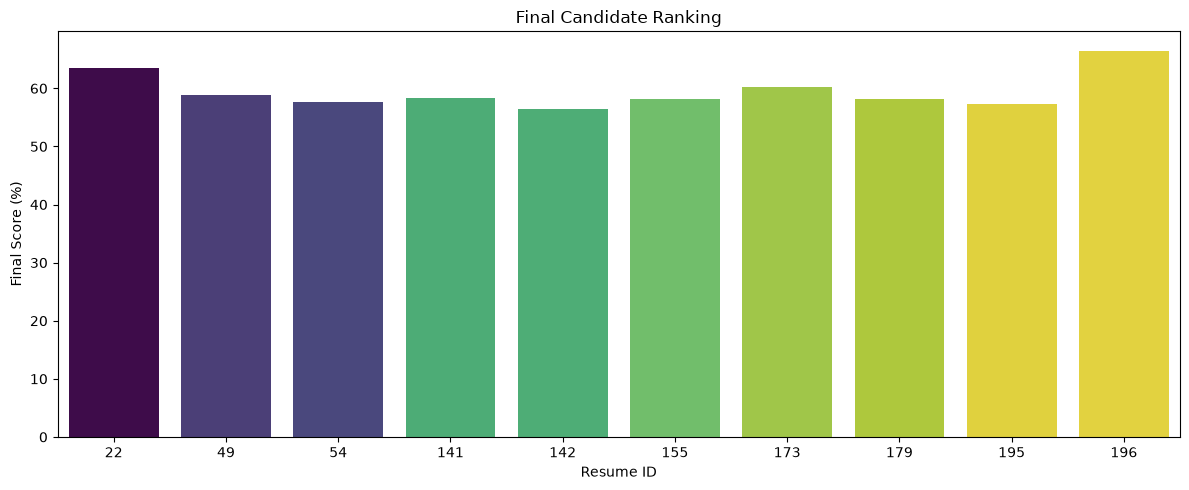

In [19]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=final_df,
    x="Resume_ID",
    y="Final_Score",
    hue="Resume_ID",
    palette="viridis",
    legend=False
)

plt.title("Final Candidate Ranking")
plt.xlabel("Resume ID")
plt.ylabel("Final Score (%)")

plt.tight_layout()
plt.show()

In [18]:
comparison_df = final_df[[
    "Resume_ID",
    "Semantic_Percentage",
    "Skill_Percentage",
    "Final_Score"
]]

comparison_df

,Resume_ID,Semantic_Percentage,Skill_Percentage,Final_Score
Final Rank,,,,
1,196,64.989998,70.0,66.49
2,22,60.680000,70.0,63.48
3,173,60.389999,60.0,60.27
4,49,54.049999,70.0,58.83
5,141,53.310001,70.0,58.32
6,179,61.770000,50.0,58.24
7,155,57.490002,60.0,58.24
8,54,56.740002,60.0,57.72
9,195,51.790001,70.0,57.25
